# O2O优惠券使用行为探索性分析

本阶段基于处理后的领券样本，从整体核销情况、距离、优惠力度及时间等维度分析用户优惠券使用行为，为后续用户画像、特征工程和预测模型建立提供依据。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/processed/coupon_basic.parquet")
FIGURE_DIR = Path("../output/figures")
TABLE_DIR = Path("../output/tables")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

coupon_data = pd.read_parquet(DATA_PATH)

print("数据读取完成")
print("数据形状：", coupon_data.shape)

coupon_data.head()

数据读取完成
数据形状： (1053282, 19)


,User_id,Merchant_id,Coupon_id,Discount_rate,Distance,Date_received,Date,days_to_use,label,is_manjian,discount_rate_value,discount_threshold,discount_reduction,distance_missing,distance_value,receive_month,receive_day,receive_weekday,is_weekend
0,1439408,4663,11002.0,150:20,1.0,2016-05-28,NaT,NaN,0,1,0.866667,150.0,20.0,0,1.0,5,28,5,1
1,1439408,2632,8591.0,20:1,0.0,2016-02-17,NaT,NaN,0,1,0.950000,20.0,1.0,0,0.0,2,17,2,0
2,1439408,2632,1078.0,20:1,0.0,2016-03-19,NaT,NaN,0,1,0.950000,20.0,1.0,0,0.0,3,19,5,1
3,1439408,2632,8591.0,20:1,0.0,2016-06-13,NaT,NaN,0,1,0.950000,20.0,1.0,0,0.0,6,13,0,0
4,1439408,2632,8591.0,20:1,0.0,2016-05-16,2016-06-13,28.0,0,1,0.950000,20.0,1.0,0,0.0,5,16,0,0


## 1. 整体优惠券核销情况

首先统计优惠券领取后的15天内核销情况，了解整体优惠券转化水平，并作为后续分维度分析的基准。

In [3]:
# 统计整体核销情况
redeem_count = coupon_data["label"].value_counts().sort_index()
redeem_rate = coupon_data["label"].mean()

print("领券记录总数：", len(coupon_data))
print("未在15天内核销：", redeem_count[0])
print("15天内核销：", redeem_count[1])
print("15天内核销率：", f"{redeem_rate:.2%}")

领券记录总数： 1053282
未在15天内核销： 988887
15天内核销： 64395
15天内核销率： 6.11%


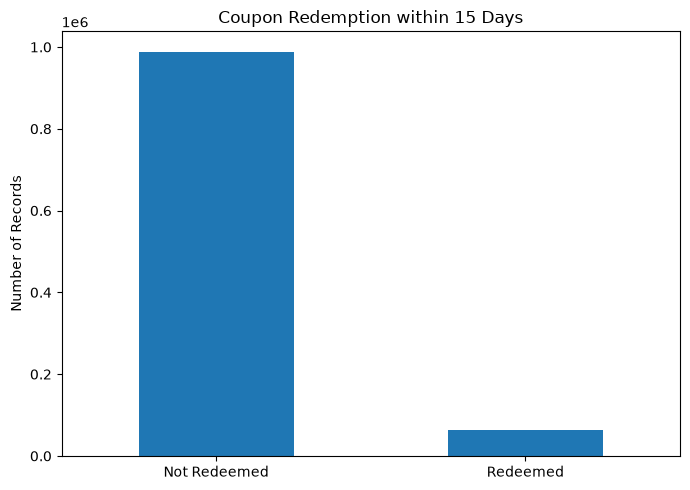

In [4]:
# 绘制整体核销情况
plot_data = pd.Series({
    "Not Redeemed": redeem_count[0],
    "Redeemed": redeem_count[1]
})

fig, ax = plt.subplots(figsize=(7, 5))

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Coupon Redemption within 15 Days")
ax.set_xlabel("")
ax.set_ylabel("Number of Records")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "01_overall_redemption.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [5]:
# 计算核销比例
redeem_rate_table = pd.DataFrame({
    "count": redeem_count,
    "rate": (redeem_count / len(coupon_data) * 100).round(2)
})

redeem_rate_table.index = ["未在15天内核销", "15天内核销"]

redeem_rate_table

,count,rate
未在15天内核销,988887,93.89
15天内核销,64395,6.11


## 2. 距离与优惠券核销率

分析用户与商户之间的距离等级是否会影响优惠券核销行为，从而判断地理距离是否是优惠券精准投放的重要因素。

In [6]:
# 按距离等级统计领券数量、核销数量和核销率
distance_analysis = (
    coupon_data[coupon_data["Distance"].notna()]
    .groupby("Distance")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
    .reset_index()
)

distance_analysis["redeem_rate"] *= 100

distance_analysis

,Distance,coupon_count,redeem_count,redeem_rate
0,0.0,348179,40281,11.569049
1,1.0,143871,7212,5.012824
2,2.0,81279,2868,3.528587
3,3.0,54944,1488,2.708212
4,4.0,40542,1041,2.567708
5,5.0,31010,680,2.192841
6,6.0,24658,494,2.003407
7,7.0,19682,326,1.656336
8,8.0,16404,319,1.944648
9,9.0,13961,265,1.898145


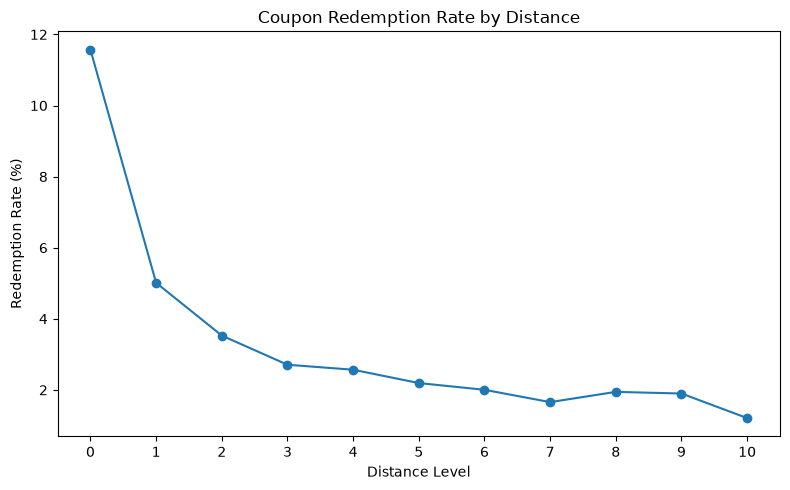

In [7]:
# 绘制不同距离等级的核销率
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    distance_analysis["Distance"],
    distance_analysis["redeem_rate"],
    marker="o"
)

ax.set_title("Coupon Redemption Rate by Distance")
ax.set_xlabel("Distance Level")
ax.set_ylabel("Redemption Rate (%)")
ax.set_xticks(distance_analysis["Distance"])

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "02_redemption_rate_by_distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# 比较距离已知与未知用户的核销率
distance_missing_analysis = (
    coupon_data
    .groupby("distance_missing")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
)

distance_missing_analysis["redeem_rate"] *= 100

distance_missing_analysis.index = [
    "距离已知",
    "距离未知"
]

distance_missing_analysis

,coupon_count,redeem_count,redeem_rate
距离已知,947279,57060,6.023569
距离未知,106003,7335,6.919615


**分析结论：** 优惠券核销率整体随用户与商户距离增加而下降。距离等级为0的用户15天内核销率达到11.57%，而距离等级为10时仅为1.21%，表明地理距离与优惠券核销行为存在明显负向关联。此外，距离信息缺失用户的核销率为6.92%，略高于距离已知用户，因此后续建模中保留距离缺失标记作为独立特征。

## 3. 优惠力度与优惠券核销率

分析不同折扣力度下的优惠券核销表现，判断提高优惠力度是否能够有效促进用户核销。

In [9]:
# 查看折扣率的基本分布
coupon_data["discount_rate_value"].describe()

count    1.053282e+06
mean     8.443335e-01
std      9.036359e-02
min      2.000000e-01
25%      8.333333e-01
50%      8.500000e-01
75%      9.000000e-01
max      9.900000e-01
Name: discount_rate_value, dtype: float64

In [10]:
# 将实际折扣率划分为不同区间
bins = [0, 0.6, 0.7, 0.8, 0.9, 1.0]

labels = [
    "≤60%",
    "60%-70%",
    "70%-80%",
    "80%-90%",
    "90%-100%"
]

coupon_data["discount_group"] = pd.cut(
    coupon_data["discount_rate_value"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

coupon_data["discount_group"].value_counts().sort_index()

discount_group
≤60%         36815
60%-70%      51248
70%-80%     146089
80%-90%     714216
90%-100%    104914
Name: count, dtype: int64

In [11]:
discount_analysis = (
    coupon_data
    .groupby("discount_group", observed=True)
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
    .reset_index()
)

discount_analysis["redeem_rate"] *= 100

discount_analysis

,discount_group,coupon_count,redeem_count,redeem_rate
0,≤60%,36815,3462,9.403776
1,60%-70%,51248,1006,1.963003
2,70%-80%,146089,14841,10.158876
3,80%-90%,714216,32977,4.617231
4,90%-100%,104914,12109,11.541834


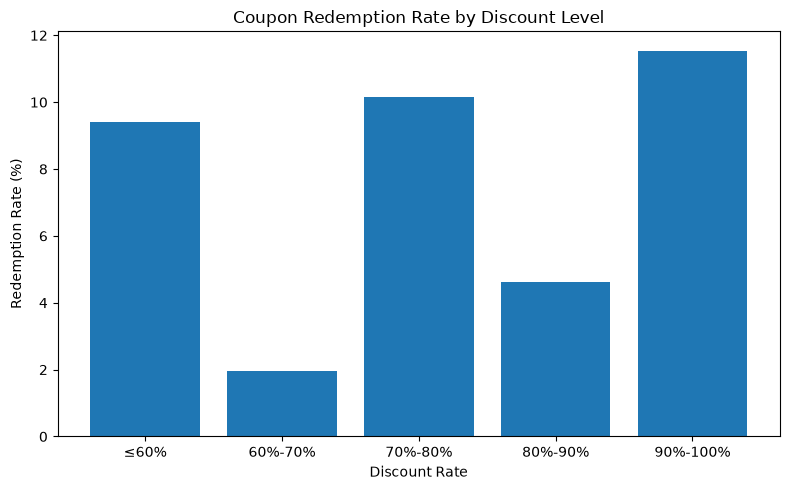

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    discount_analysis["discount_group"].astype(str),
    discount_analysis["redeem_rate"]
)

ax.set_title("Coupon Redemption Rate by Discount Level")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Redemption Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "03_redemption_rate_by_discount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**分析结论：** 不同折扣区间的优惠券核销率存在明显差异，但并未呈现“优惠力度越大、核销率越高”的单调关系。其中90%-100%折扣区间核销率最高，为11.54%，而60%-70%区间仅为1.96%。这说明仅使用等效折扣率无法充分解释核销行为，优惠券类型及满减门槛可能同时影响用户的使用决策，因此需要进一步拆分分析。

## 4. 优惠券类型与核销率

比较满减券与直接折扣券的核销表现，分析不同优惠机制对用户使用行为的影响。

In [13]:
coupon_type_analysis = (
    coupon_data
    .groupby("is_manjian")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
)

coupon_type_analysis["redeem_rate"] *= 100

coupon_type_analysis.index = [
    "直接折扣券",
    "满减券"
]

coupon_type_analysis

,coupon_count,redeem_count,redeem_rate
直接折扣券,33272,3852,11.577302
满减券,1020010,60543,5.935530


In [14]:
# 提取满减券
manjian_data = coupon_data[
    coupon_data["is_manjian"] == 1
].copy()

manjian_data["discount_threshold"].describe()

count    1.020010e+06
mean     8.099656e+01
std      7.218772e+01
min      5.000000e+00
25%      3.000000e+01
50%      5.000000e+01
75%      1.000000e+02
max      3.000000e+02
Name: discount_threshold, dtype: float64

In [15]:
manjian_data["discount_threshold"].value_counts().head(15)

discount_threshold
30.0     301082
100.0    242411
200.0    146602
20.0     143232
50.0      87397
10.0      43767
300.0     29264
150.0     23729
5.0        2526
Name: count, dtype: int64

**分析结论：** 直接折扣券的15天内核销率为11.58%，明显高于满减券的5.94%。同时，满减券占全部领券样本的绝大多数，说明优惠券使用机制可能与用户核销行为存在较强关联。由于满减券还受到消费门槛的约束，下面进一步分析不同满减门槛与核销率之间的关系。

## 5. 满减门槛与核销率

针对满减券进一步分析不同消费门槛下的优惠券核销表现，判断较高的使用门槛是否会降低用户的核销意愿。

In [16]:
# 按满减门槛统计核销情况
threshold_analysis = (
    manjian_data
    .groupby("discount_threshold")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
    .reset_index()
    .sort_values("discount_threshold")
)

threshold_analysis["redeem_rate"] *= 100

threshold_analysis

,discount_threshold,coupon_count,redeem_count,redeem_rate
0,5.0,2526,563,22.288203
1,10.0,43767,6343,14.492654
2,20.0,143232,18804,13.128351
3,30.0,301082,22731,7.549770
4,50.0,87397,4217,4.825108
5,100.0,242411,5755,2.374067
6,150.0,23729,343,1.445489
7,200.0,146602,1504,1.025907
8,300.0,29264,283,0.967059


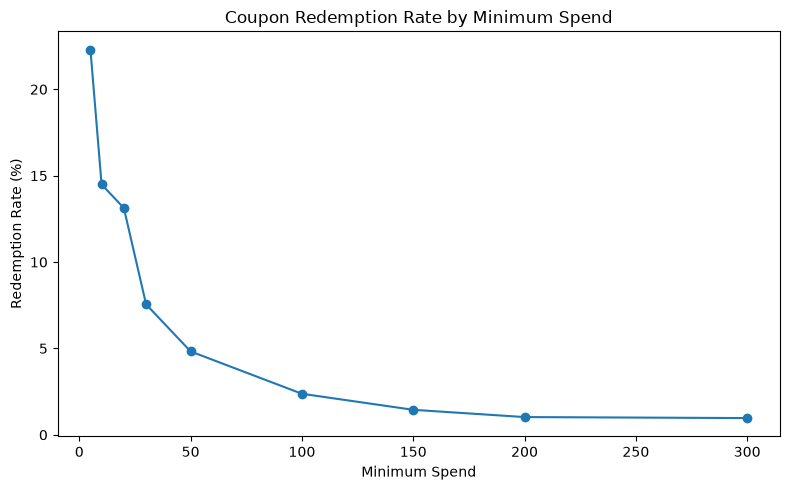

In [17]:
# 绘制不同满减门槛的核销率
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    threshold_analysis["discount_threshold"],
    threshold_analysis["redeem_rate"],
    marker="o"
)

ax.set_title("Coupon Redemption Rate by Minimum Spend")
ax.set_xlabel("Minimum Spend")
ax.set_ylabel("Redemption Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "04_redemption_rate_by_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# 查看不同减免金额的分布
manjian_data["discount_reduction"].describe()

count    1.020010e+06
mean     1.071230e+01
std      9.114281e+00
min      1.000000e+00
25%      5.000000e+00
50%      5.000000e+00
75%      2.000000e+01
max      1.000000e+02
Name: discount_reduction, dtype: float64

In [19]:
manjian_data["discount_reduction"].value_counts().head(15)

discount_reduction
5.0      440146
10.0     230135
20.0     151063
30.0      97165
1.0       93618
50.0       7871
100.0        12
Name: count, dtype: int64

**分析结论：** 满减券核销率整体随消费门槛提高而明显下降。5元门槛优惠券的15天内核销率达到22.29%，而300元门槛仅为0.97%。相比前面的等效折扣率分析，消费门槛与核销行为呈现出更清晰的负向关联，说明优惠券的使用成本可能是影响用户核销决策的重要因素。

## 6. 减免金额与核销率

进一步分析不同减免金额下满减券的核销表现，并结合消费门槛判断优惠金额与使用条件对用户核销行为的共同影响。

In [20]:
# 按减免金额统计核销情况
reduction_analysis = (
    manjian_data
    .groupby("discount_reduction")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
    .reset_index()
    .sort_values("discount_reduction")
)

reduction_analysis["redeem_rate"] *= 100

reduction_analysis

,discount_reduction,coupon_count,redeem_count,redeem_rate
0,1.0,93618,13294,14.200261
1,5.0,440146,37942,8.620321
2,10.0,230135,5346,2.322984
3,20.0,151063,2465,1.631770
4,30.0,97165,1223,1.258684
5,50.0,7871,272,3.455724
6,100.0,12,1,8.333333


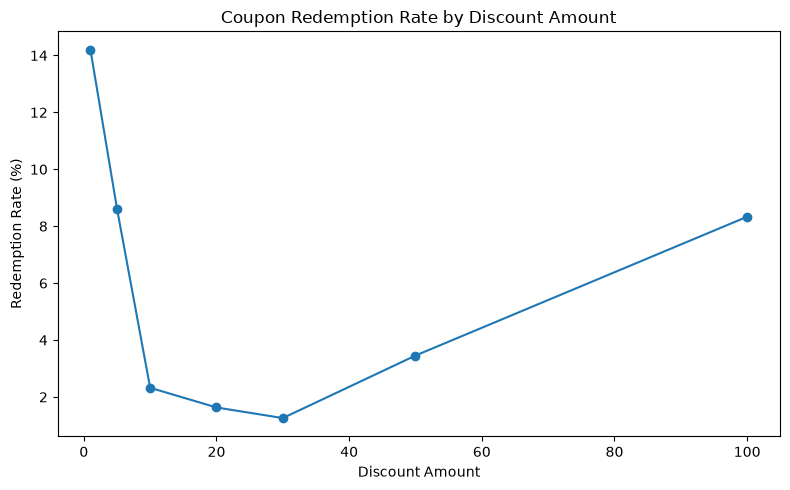

In [21]:
# 绘制不同减免金额的核销率
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    reduction_analysis["discount_reduction"],
    reduction_analysis["redeem_rate"],
    marker="o"
)

ax.set_title("Coupon Redemption Rate by Discount Amount")
ax.set_xlabel("Discount Amount")
ax.set_ylabel("Redemption Rate (%)")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "05_redemption_rate_by_reduction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**分析结论：** 不同减免金额的核销率并未呈现简单的单调关系。减1元优惠券的核销率达到14.20%，而减10～30元优惠券的核销率反而较低。由于不同减免金额通常对应不同消费门槛，因此不能仅根据减免金额判断优惠效果，需要进一步结合“消费门槛—减免金额”的具体优惠组合进行分析。此外，减100元优惠券仅有12条样本，其核销率代表性有限。

## 7. 满减组合与核销率

将消费门槛与减免金额结合，比较不同满减方案的实际核销表现，从优惠券设计角度识别更容易促成用户核销的优惠组合。

In [22]:
# 构造满减组合
manjian_data["coupon_scheme"] = (
    "满"
    + manjian_data["discount_threshold"].astype(int).astype(str)
    + "减"
    + manjian_data["discount_reduction"].astype(int).astype(str)
)

manjian_data[
    [
        "Discount_rate",
        "discount_threshold",
        "discount_reduction",
        "coupon_scheme"
    ]
].head(20)

,Discount_rate,discount_threshold,discount_reduction,coupon_scheme
0,150:20,150.0,20.0,满150减20
1,20:1,20.0,1.0,满20减1
2,20:1,20.0,1.0,满20减1
3,20:1,20.0,1.0,满20减1
4,20:1,20.0,1.0,满20减1
5,200:20,200.0,20.0,满200减20
6,200:20,200.0,20.0,满200减20
7,30:5,30.0,5.0,满30减5
8,20:1,20.0,1.0,满20减1
9,50:10,50.0,10.0,满50减10


In [23]:
# 统计不同满减组合的核销情况
scheme_analysis = (
    manjian_data
    .groupby(
        [
            "coupon_scheme",
            "discount_threshold",
            "discount_reduction"
        ]
    )
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
    .reset_index()
)

scheme_analysis["redeem_rate"] *= 100

# 按样本数量从高到低排列
scheme_analysis = scheme_analysis.sort_values(
    "coupon_count",
    ascending=False
)

scheme_analysis

,coupon_scheme,discount_threshold,discount_reduction,coupon_count,redeem_count,redeem_rate
29,满30减5,30.0,5.0,270712,20404,7.537161
1,满100减10,100.0,10.0,182554,3904,2.138545
15,满200减20,200.0,20.0,111046,1192,1.073429
21,满20减5,20.0,5.0,91013,11796,12.960786
19,满20减1,20.0,1.0,51705,6941,13.424234
34,满50减5,50.0,5.0,47379,2657,5.607970
3,满100减30,100.0,30.0,38196,683,1.788145
16,满200减30,200.0,30.0,29327,199,0.678556
24,满300减30,300.0,30.0,28979,269,0.928258
31,满50减10,50.0,10.0,28452,953,3.349501


In [24]:
# 筛选样本量较充足的满减方案
major_schemes = scheme_analysis[
    scheme_analysis["coupon_count"] >= 1000
].copy()

major_schemes = major_schemes.sort_values(
    "redeem_rate",
    ascending=False
)

major_schemes

,coupon_scheme,discount_threshold,discount_reduction,coupon_count,redeem_count,redeem_rate
35,满5减1,5.0,1.0,2526,563,22.288203
6,满10减1,10.0,1.0,17842,3513,19.689497
19,满20减1,20.0,1.0,51705,6941,13.424234
21,满20减5,20.0,5.0,91013,11796,12.960786
26,满30减1,30.0,1.0,17654,2015,11.413844
7,满10减5,10.0,5.0,25925,2830,10.916104
5,满100减50,100.0,50.0,1774,162,9.131905
29,满30减5,30.0,5.0,270712,20404,7.537161
30,满50减1,50.0,1.0,3354,235,7.006559
34,满50减5,50.0,5.0,47379,2657,5.607970


In [25]:
# 样本量充足的满减方案中，核销率最高的 Top 10
top10_schemes = major_schemes.head(10)

top10_schemes[
    [
        "coupon_scheme",
        "coupon_count",
        "redeem_count",
        "redeem_rate"
    ]
]

,coupon_scheme,coupon_count,redeem_count,redeem_rate
35,满5减1,2526,563,22.288203
6,满10减1,17842,3513,19.689497
19,满20减1,51705,6941,13.424234
21,满20减5,91013,11796,12.960786
26,满30减1,17654,2015,11.413844
7,满10减5,25925,2830,10.916104
5,满100减50,1774,162,9.131905
29,满30减5,270712,20404,7.537161
30,满50减1,3354,235,7.006559
34,满50减5,47379,2657,5.607970


In [26]:
# 样本量充足的满减方案中，核销率最低的 Top 10
bottom10_schemes = (
    major_schemes
    .sort_values("redeem_rate")
    .head(10)
)

bottom10_schemes[
    [
        "coupon_scheme",
        "coupon_count",
        "redeem_count",
        "redeem_rate"
    ]
]

,coupon_scheme,coupon_count,redeem_count,redeem_rate
16,满200减30,29327,199,0.678556
24,满300减30,28979,269,0.928258
9,满150减20,17437,171,0.980673
15,满200减20,111046,1192,1.073429
18,满200减50,5585,93,1.665175
8,满150减10,5325,91,1.708920
3,满100减30,38196,683,1.788145
1,满100减10,182554,3904,2.138545
27,满30减10,12692,311,2.450362
31,满50减10,28452,953,3.349501


In [28]:
# 设置 Matplotlib 中文字体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

print("中文字体设置完成")

中文字体设置完成


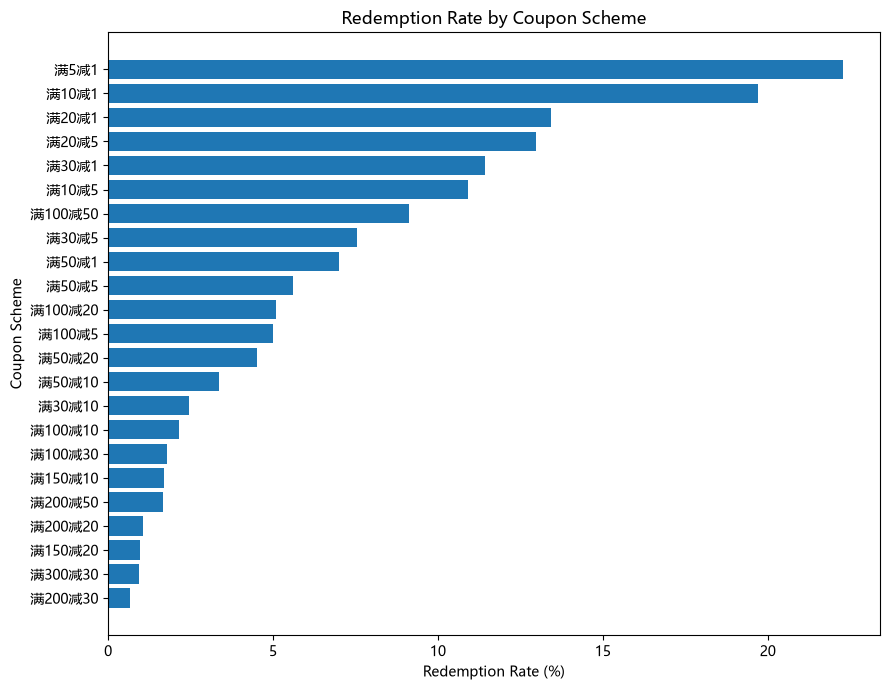

In [29]:
# 按核销率排序
plot_schemes = major_schemes.sort_values(
    "redeem_rate",
    ascending=True
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    plot_schemes["coupon_scheme"],
    plot_schemes["redeem_rate"]
)

ax.set_title("Redemption Rate by Coupon Scheme")
ax.set_xlabel("Redemption Rate (%)")
ax.set_ylabel("Coupon Scheme")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "06_redemption_rate_by_scheme.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**分析结论：** 在样本量不少于1000的满减方案中，低门槛优惠券整体表现出较高的核销率。例如“满20减1”和“满200减20”的等效折扣率均为95%，但15天内核销率分别为13.42%和1.07%，相差约12.5倍。类似现象表明，仅依赖折扣力度难以准确衡量优惠券吸引力，消费门槛可能是区分优惠券核销表现的重要因素。营销策略上应避免仅通过提高满减金额增强优惠感知，还需要综合考虑用户实际达到消费门槛的难度。

## 8. 时间维度与优惠券核销率

从优惠券领取时间出发，分析不同月份、星期及工作日与周末的核销表现，观察用户优惠券使用行为是否存在时间差异。

In [30]:
# 工作日与周末核销情况
weekend_analysis = (
    coupon_data
    .groupby("is_weekend")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
)

weekend_analysis["redeem_rate"] *= 100

weekend_analysis.index = [
    "工作日",
    "周末"
]

weekend_analysis

,coupon_count,redeem_count,redeem_rate
工作日,700457,45483,6.493332
周末,352825,18912,5.360164


In [31]:
# 按星期统计核销情况
weekday_analysis = (
    coupon_data
    .groupby("receive_weekday")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
    .reset_index()
)

weekday_analysis["redeem_rate"] *= 100

weekday_names = {
    0: "周一",
    1: "周二",
    2: "周三",
    3: "周四",
    4: "周五",
    5: "周六",
    6: "周日"
}

weekday_analysis["weekday_name"] = (
    weekday_analysis["receive_weekday"]
    .map(weekday_names)
)

weekday_analysis

,receive_weekday,coupon_count,redeem_count,redeem_rate,weekday_name
0,0,162069,9111,5.621680,周一
1,1,114792,8690,7.570214,周二
2,2,122754,9096,7.409942,周三
3,3,132771,8377,6.309360,周四
4,4,168071,10209,6.074219,周五
5,5,160211,9245,5.770515,周六
6,6,192614,9667,5.018846,周日


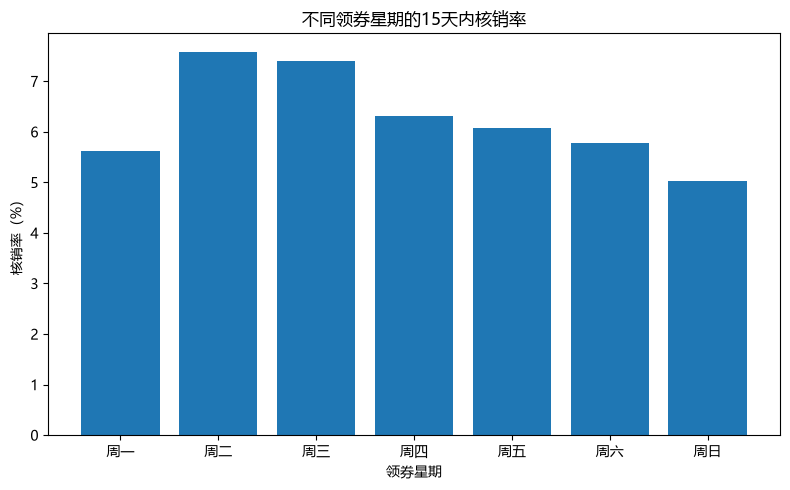

In [32]:
# 绘制星期维度核销率
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    weekday_analysis["weekday_name"],
    weekday_analysis["redeem_rate"]
)

ax.set_title("不同领券星期的15天内核销率")
ax.set_xlabel("领券星期")
ax.set_ylabel("核销率（%）")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "07_redemption_rate_by_weekday.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. 用户领券行为分析

从用户维度统计领券次数、核销次数及核销率，分析不同活跃程度用户的优惠券使用行为差异。

In [33]:
# 按用户统计领券与核销行为
user_analysis = (
    coupon_data
    .groupby("User_id")
    .agg(
        coupon_count=("label", "size"),
        redeem_count=("label", "sum"),
        redeem_rate=("label", "mean")
    )
    .reset_index()
)

user_analysis["redeem_rate"] *= 100

print("用户数量：", len(user_analysis))

user_analysis.head(10)

用户数量： 510698


,User_id,coupon_count,redeem_count,redeem_rate
0,4,2,0,0.0
1,35,4,0,0.0
2,36,2,0,0.0
3,64,1,0,0.0
4,110,3,0,0.0
5,144,1,0,0.0
6,147,1,0,0.0
7,165,3,0,0.0
8,166,1,0,0.0
9,173,1,0,0.0


In [34]:
# 查看用户领券次数分布
user_analysis["coupon_count"].describe()

count    510698.000000
mean          2.062436
std           2.051864
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max         120.000000
Name: coupon_count, dtype: float64

In [35]:
# 根据领券次数划分用户活跃度
def classify_user_activity(x):
    if x == 1:
        return "低频用户"
    elif x <= 3:
        return "中频用户"
    else:
        return "高频用户"

user_analysis["activity_group"] = (
    user_analysis["coupon_count"]
    .apply(classify_user_activity)
)

# 查看各类用户数量
user_analysis["activity_group"].value_counts()

activity_group
低频用户    294345
中频用户    147521
高频用户     68832
Name: count, dtype: int64

In [36]:
# 不同活跃度用户的领券与核销表现
activity_analysis = (
    user_analysis
    .groupby("activity_group")
    .agg(
        user_count=("User_id", "size"),
        avg_coupon_count=("coupon_count", "mean"),
        total_coupon_count=("coupon_count", "sum"),
        total_redeem_count=("redeem_count", "sum")
    )
)

# 按“该群体实际领取的券”计算整体核销率
activity_analysis["redeem_rate"] = (
    activity_analysis["total_redeem_count"]
    / activity_analysis["total_coupon_count"]
    * 100
)

# 固定展示顺序
activity_analysis = activity_analysis.reindex(
    ["低频用户", "中频用户", "高频用户"]
)

activity_analysis.round(2)

,user_count,avg_coupon_count,total_coupon_count,total_redeem_count,redeem_rate
activity_group,,,,,
低频用户,294345,1.00,294345,8149,2.77
中频用户,147521,2.31,340773,19035,5.59
高频用户,68832,6.08,418164,37211,8.90


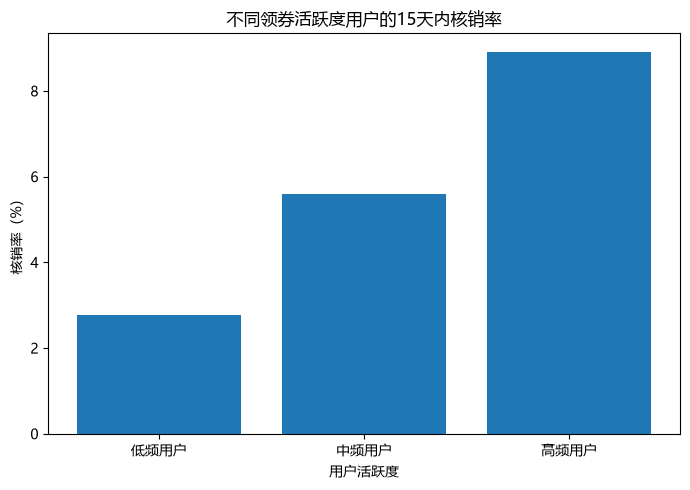

In [37]:
# 不同活跃度用户核销率
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    activity_analysis.index,
    activity_analysis["redeem_rate"]
)

ax.set_title("不同领券活跃度用户的15天内核销率")
ax.set_xlabel("用户活跃度")
ax.set_ylabel("核销率（%）")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "08_redemption_rate_by_user_activity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# 标记用户是否至少核销过一次优惠券
user_analysis["has_redeemed"] = (
    user_analysis["redeem_count"] > 0
).astype(int)

redeemed_user_summary = (
    user_analysis["has_redeemed"]
    .value_counts()
    .sort_index()
)

redeemed_user_rate = (
    user_analysis["has_redeemed"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("从未核销用户：", redeemed_user_summary[0])
print("至少核销过一次的用户：", redeemed_user_summary[1])

print("\n用户占比：")
print(
    pd.DataFrame({
        "用户数": redeemed_user_summary,
        "占比(%)": redeemed_user_rate.round(2)
    })
)

从未核销用户： 470623
至少核销过一次的用户： 40075

用户占比：
                 用户数  占比(%)
has_redeemed               
0             470623  92.15
1              40075   7.85


In [39]:
# 不同活跃度用户中，至少核销过一次的用户比例
activity_user_response = (
    user_analysis
    .groupby("activity_group")
    .agg(
        user_count=("User_id", "size"),
        redeemed_user_count=("has_redeemed", "sum"),
        redeemed_user_rate=("has_redeemed", "mean")
    )
)

activity_user_response["redeemed_user_rate"] *= 100

activity_user_response = activity_user_response.reindex(
    ["低频用户", "中频用户", "高频用户"]
)

activity_user_response.round(2)

,user_count,redeemed_user_count,redeemed_user_rate
activity_group,,,
低频用户,294345,8149,2.77
中频用户,147521,14890,10.09
高频用户,68832,17036,24.75
